In [1]:
%load_ext jupyter_black

In [2]:
import lamindb as ln
import pickle
import ovrlpy
import spatialdata as sd
import matplotlib.pyplot as plt

→ connected lamindb: scverse/spatialdata-db


/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [3]:
# we will download the dataset "Xenium FFPE Healthy Human Breast", provided from 10x Genomics https://www.10xgenomics.com/datasets/ffpe-human-breast-with-custom-add-on-panel-1-standard
artifact = ln.Artifact.get("Uj7J4jjgzHw0lcm80001")
gb = artifact.size / 1_000_000_000
print(f"{gb:.2f} GB")

7.23 GB


In [4]:
artifact.cache()
f = artifact._cache_path

! run input wasn't tracked, call `ln.track()` and re-run


In [5]:
sdata = sd.read_zarr(str(f))

/tmp/ipykernel_40593/165303993.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr(str(f))
/Users/macbook/embl/projects/basel/3d-spatial-workshop-2025/.venv/lib/python3.12/site-packages/zarr/core/group.py:3530: ZarrUserWarning: Object at .DS_Store is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


In [6]:
transcripts = sdata["transcripts"].compute()
transcripts["gene"] = transcripts["feature_name"]

In [7]:
COMPUTE = True
COMPUTE = False

if COMPUTE:
    dataset = ovrlpy.Ovrlp(
        transcripts,
        n_components=20,
        n_workers=4,
    )
    dataset.analyse()

    with open("data/analysis.pickle", "wb") as file:
        pickle.dump(dataset, file)

In [8]:
with open("data/analysis.pickle", "rb") as file:
    dataset = pickle.load(file)

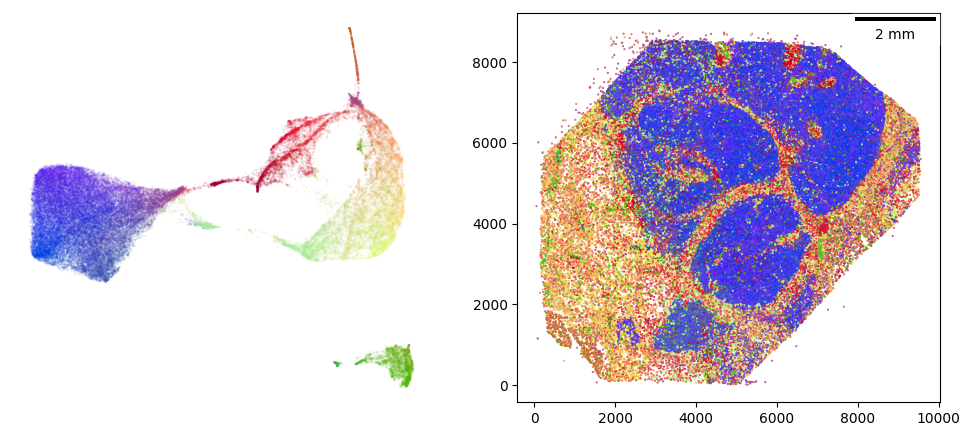

In [9]:
ovrlpy.plot_pseudocells(dataset)
plt.show()

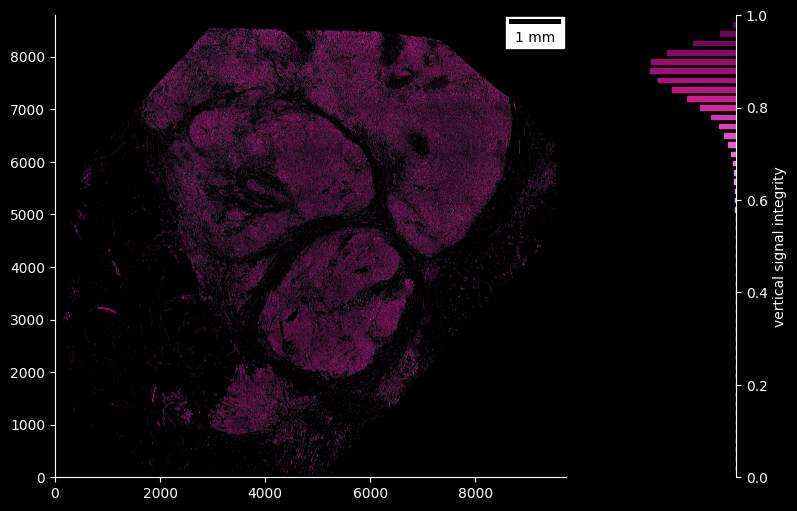

In [10]:
fig = ovrlpy.plot_signal_integrity(dataset, signal_threshold=3)
plt.show()

In [11]:
doublets = dataset.detect_doublets(min_signal=3, integrity_sigma=2)

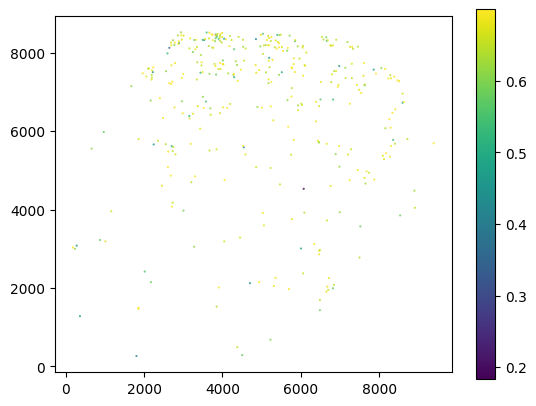

In [12]:
fig, ax = plt.subplots()
_scatter = ax.scatter(
    doublets["x"], doublets["y"], c=doublets["integrity"], s=0.2, cmap="viridis"
)
_ = ax.set_aspect("equal")
_ = fig.colorbar(_scatter, ax=ax)
plt.show()

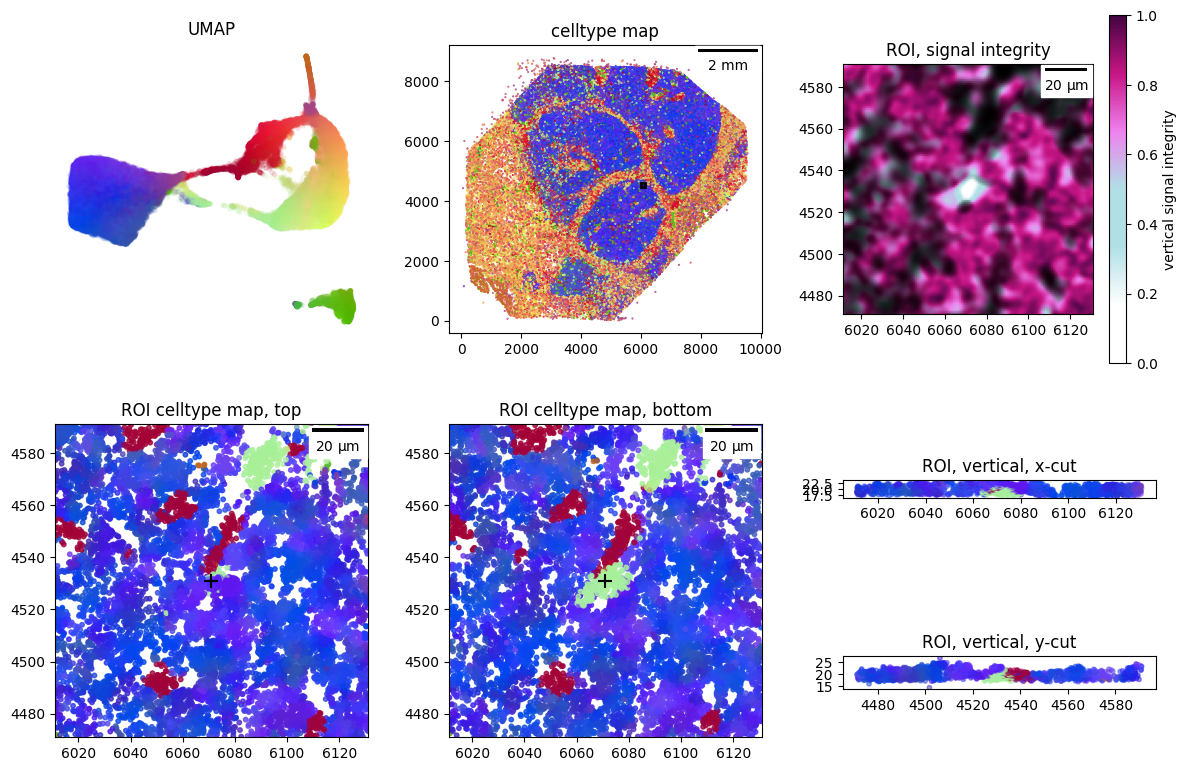

In [13]:
x, y = doublets["x", "y"].row(0)
_ = ovrlpy.plot_region_of_interest(dataset, x, y, window_size=60)
plt.show()